In [1]:
import pandas as pd

df = pd.read_csv(r"datasets/meta_data/audio_meta_data.csv")
df.head()


,episode_id,trancription_id,num_speakers,transcript_available,category,duration_seconds,source
0,audio1.mp3,audio1.txt,1,yes,podcast,3397.88,hacker public radio
1,audio2.mp3,audio2.txt,1,yes,podcast,2415.60,hacker public radio
2,audio3.mp3,audio3.txt,1,yes,podcast,1705.20,hacker public radio
3,audio4.mp3,audio4.txt,1,yes,podcast,1096.20,hacker public radio
4,audio5.mp3,audio5.txt,2,yes,podcast,1888.80,hacker public radio


In [2]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
audio_folder = "datasets/raw_audio"
transcript_folder = "datasets/transcripts"
metadata_folder = "datasets/meta_data"



In [9]:
audio_data = []

for file in os.listdir(audio_folder):
    if file.lower().endswith((".wav", ".mp3")):
        path = os.path.join(audio_folder, file)

        duration = librosa.get_duration(path=path)
        sr = librosa.get_samplerate(path)
        size = os.path.getsize(path) / (1024 * 1024)  # MB

        # load short sample for noise analysis
        y, _ = librosa.load(path, duration=5)

        noise_level = np.mean(np.abs(y))   # simple noise indicator

        audio_data.append([file, duration, sr, size, noise_level])

audio_df = pd.DataFrame(audio_data, columns=[
    "file", "duration_sec", "sample_rate", "size_MB", "noise_level"
])

audio_df.head()


,file,duration_sec,sample_rate,size_MB,noise_level
0,audio1.mp3,3394.461563,48000,25.899728,0.131237
1,audio10.mp3,2618.172979,48000,30.019631,0.104378
2,audio11.mp3,864.036979,48000,9.913211,0.220923
3,audio12.mp3,1308.252979,48000,15.017296,0.142120
4,audio13.mp3,3707.508979,48000,42.504301,0.044135


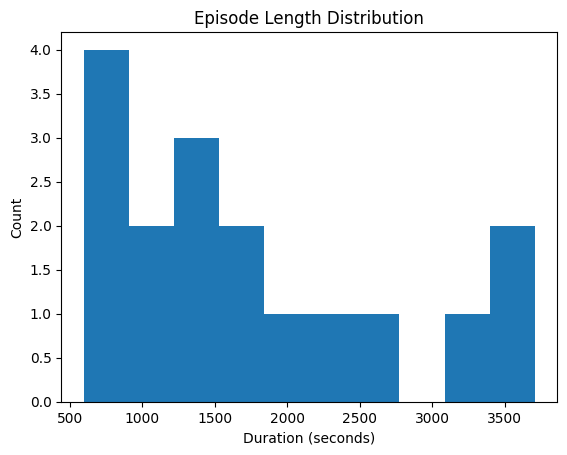

In [10]:
plt.hist(audio_df["duration_sec"], bins=10)
plt.title("Episode Length Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()


In [11]:

print("Sampling Rate Counts:")
print(audio_df["sample_rate"].value_counts())


Sampling Rate Counts:
sample_rate
48000    16
44100     1
Name: count, dtype: int64


In [12]:
print("Average File Size (MB):", round(audio_df["size_MB"].mean(), 2))


Average File Size (MB): 17.67


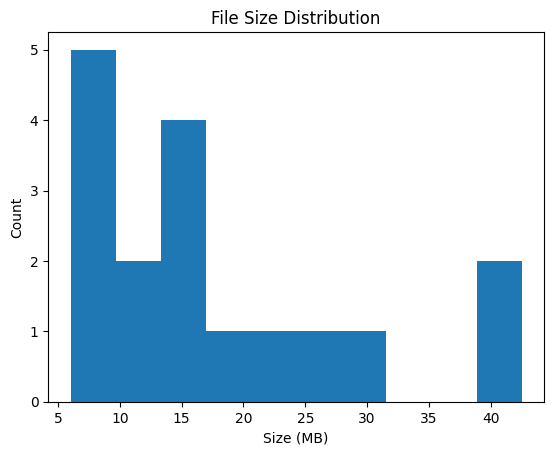

In [13]:
plt.hist(audio_df["size_MB"], bins=10)
plt.title("File Size Distribution")
plt.xlabel("Size (MB)")
plt.ylabel("Count")
plt.show()


In [14]:
print("Average Noise Level:", round(audio_df["noise_level"].mean(), 5))


Average Noise Level: 0.11494


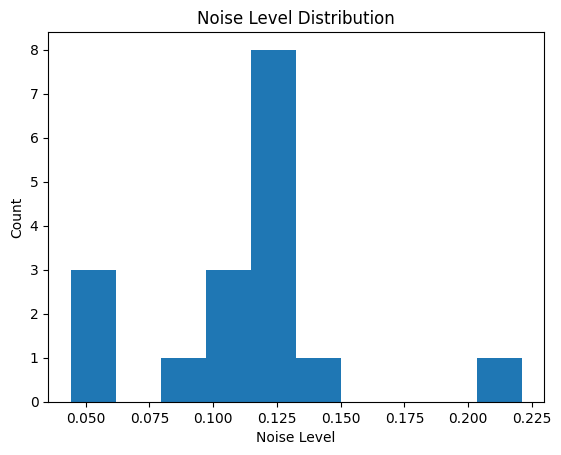

In [15]:
plt.hist(audio_df["noise_level"], bins=10)
plt.title("Noise Level Distribution")
plt.xlabel("Noise Level")
plt.ylabel("Count")
plt.show()


In [16]:
print("Noise Level Variation:", round(audio_df["noise_level"].std(), 5))


Noise Level Variation: 0.0423


In [19]:
with open(os.path.join(transcript_folder, trans_df["file"][0]), encoding="utf-8") as f:
    print(f.read()[:500])


This is Hacker Public Radio Episode 4566, for 2026-02-02
Today's show is entitled, "HPR Community News for January 2026"
The host is HPR Volunteers and the duration is 00:55:13
The flag is Explicit, and the license is CC-BY-SA
The summary is "HPR Volunteers talk about shows released and comments posted in January 2026"
Hi everybody, my name is Ken Fallon. I'm here all by myself doing the HPR Community News for January 2026.
Everybody's probably all talked out after the New Year show.
And thanks 


In [20]:
transcript_data = []

for file in os.listdir(transcript_folder):
    if file.endswith(".txt"):
        path = os.path.join(transcript_folder, file)

        with open(path, "r", encoding="utf-8") as f:
            text = f.read()

        word_count = len(text.split())
        char_count = len(text)
        line_count = text.count("\n") + 1

        transcript_data.append([file, word_count, char_count, line_count])

trans_df = pd.DataFrame(transcript_data, columns=[
    "file", "word_count", "char_count", "line_count"
])

trans_df.head()


,file,word_count,char_count,line_count
0,audio1.txt,8300,44976,742
1,audio10.txt,5714,31185,384
2,audio11.txt,2127,12401,258
3,audio12.txt,3427,17932,548
4,audio13.txt,9563,52032,589


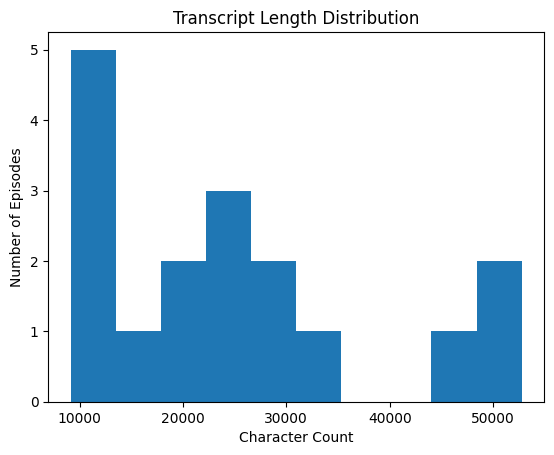

In [21]:
plt.hist(trans_df["char_count"], bins=10)
plt.title("Transcript Length Distribution")
plt.xlabel("Character Count")
plt.ylabel("Number of Episodes")
plt.show()


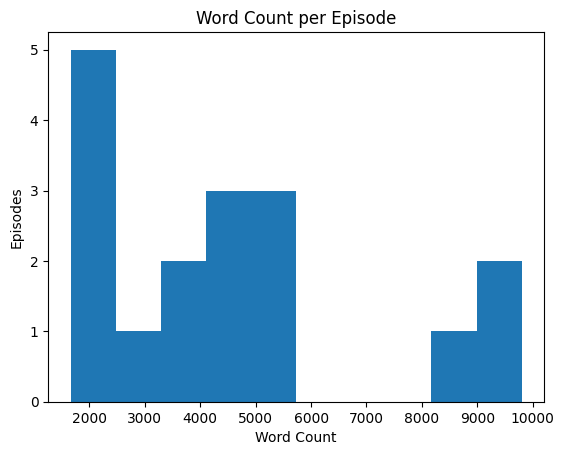

In [22]:
plt.hist(trans_df["word_count"], bins=10)
plt.title("Word Count per Episode")
plt.xlabel("Word Count")
plt.ylabel("Episodes")
plt.show()


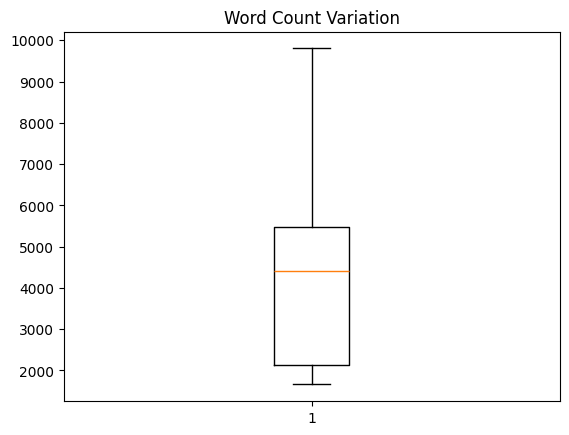

In [23]:
plt.boxplot(trans_df["word_count"])
plt.title("Word Count Variation")
plt.show()

In [24]:
print("Average words per transcript:",
      round(trans_df["word_count"].mean(), 2))


Average words per transcript: 4497.71


In [25]:
with open(os.path.join(transcript_folder, trans_df["file"][0]), encoding="utf-8") as f:
    print(f.read()[:500])


This is Hacker Public Radio Episode 4566, for 2026-02-02
Today's show is entitled, "HPR Community News for January 2026"
The host is HPR Volunteers and the duration is 00:55:13
The flag is Explicit, and the license is CC-BY-SA
The summary is "HPR Volunteers talk about shows released and comments posted in January 2026"
Hi everybody, my name is Ken Fallon. I'm here all by myself doing the HPR Community News for January 2026.
Everybody's probably all talked out after the New Year show.
And thanks 


In [26]:
timestamp_count = 0

for file in os.listdir(transcript_folder):
    if file.endswith(".txt"):
        with open(os.path.join(transcript_folder, file), encoding="utf-8") as f:
            text = f.read()

        if ":" in text or "[" in text:
            timestamp_count += 1

print("Transcripts with timestamps:", timestamp_count)


Transcripts with timestamps: 16


In [27]:
timestamp_percent = (timestamp_count / len(trans_df)) * 100
print("Timestamp presence:", round(timestamp_percent, 2), "%")


Timestamp presence: 94.12 %


In [28]:
audio_count = len(os.listdir("datasets/raw_audio"))
transcript_count = len(trans_df)

missing_percent = ((audio_count - transcript_count) / audio_count) * 100

print("Missing Transcript %:", round(missing_percent, 2))


Missing Transcript %: 5.56
